# Part 2 - Exploratory Data Analysis
Use cleaned dataset.

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import json

df=pd.read_csv('SGJobs_Cleaned_01.csv')
df.head()

,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,salary_type,status_jobStatus,title,average_salary,Industry,PostingYear,PostingMonth,PostingQuarter,CompetitionIndex,ApplicationRate
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-05-08,False,MCF-2023-0252866,2023-04-08,2023-03-30,2,5,151,...,Monthly,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0,Environment / Health,2023.0,March,Q1.0,5.0,0.033113
1,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273977,2023-04-08,2023-04-08,0,0,55,...,Monthly,Closed,"Software Engineer (Fab Support) (Java, Cim, Up...",4750.0,Information Technology,2023.0,April,Q2.0,0.0,0.000000
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-22,False,MCF-2023-0273994,2023-04-08,2023-04-08,0,7,99,...,Monthly,Closed,Senior Technician,4200.0,Repair and Maintenance,2023.0,April,Q2.0,7.0,0.070707
3,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273991,2023-04-08,2023-04-08,0,6,113,...,Monthly,Closed,"Senior .Net Developer (.Net Core, Mvc, Mvvc, S...",7500.0,Information Technology,2023.0,April,Q2.0,6.0,0.053097
4,"[{""id"":2,""category"":""Admin / Secretarial""}]",Full Time,2023-05-08,False,MCF-2023-0273976,2023-04-08,2023-04-08,0,3,99,...,Monthly,Closed,Sales / Admin Cordinator,2900.0,Admin / Secretarial,2023.0,April,Q2.0,1.0,0.030303


In [61]:
df.shape

(1048585, 26)

## Business Question 1
Which industries pay the highest salaries?

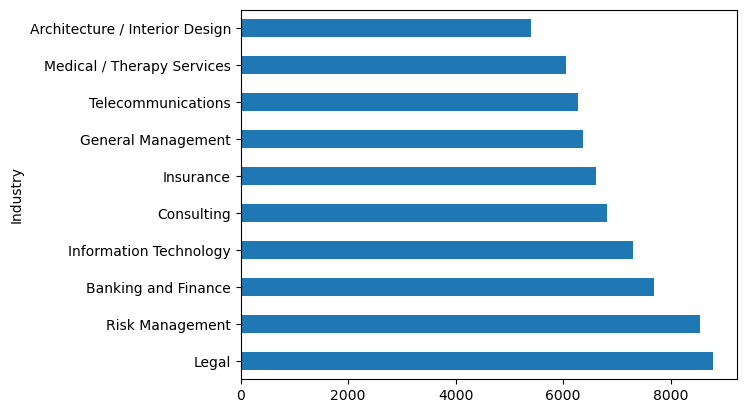

In [62]:
def first_cat(x):
 import json
 try:
  a=json.loads(x); return a[0]['category'] if a else 'Unknown'
 except: return 'Unknown'
df['Industry']=df['categories'].apply(first_cat)
salary=df.groupby('Industry')['average_salary'].mean().sort_values(ascending=False).head(10)
salary.plot(kind='barh')
plt.show()

Observation #1:

Write your findings HERE...

Business Insight

Industries with the highest vacancies are actively recruiting and provide more employment opportunities.

Dashboard Recommendation
Chart: Horizontal Bar Chart
KPI: Total Vacancies
Filters: Industry, Employment Type, Position Level

## Business Question 2. Which industries have the greatest hiring demand?
Business Objective
**
Identify which industries are hiring the largest number of people.

-Dataset Columns
-categories
-numberOfVacancies
-Data Preparation

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import json

# Create a copy
demand_df = df.copy()

# Extract first industry from JSON
def extract_category(x):
    try:
        data = json.loads(x)
        return data[0]['category'] if len(data) > 0 else 'Unknown'
    except:
        return 'Unknown'

demand_df['Industry'] = demand_df['categories'].apply(extract_category)

In [64]:
#2: Analysis:
industry_demand = (
    demand_df.groupby('Industry')['numberOfVacancies']
    .sum()
    .sort_values(ascending=False)
)

industry_demand.head(10)

Industry
F&B                                 244260
Customer Service                    240390
Information Technology              236667
Admin / Secretarial                 229399
Engineering                         190675
Healthcare / Pharmaceutical         168524
Accounting / Auditing / Taxation    164882
Building and Construction           159855
Education and Training              156371
Banking and Finance                 110853
Name: numberOfVacancies, dtype: int64

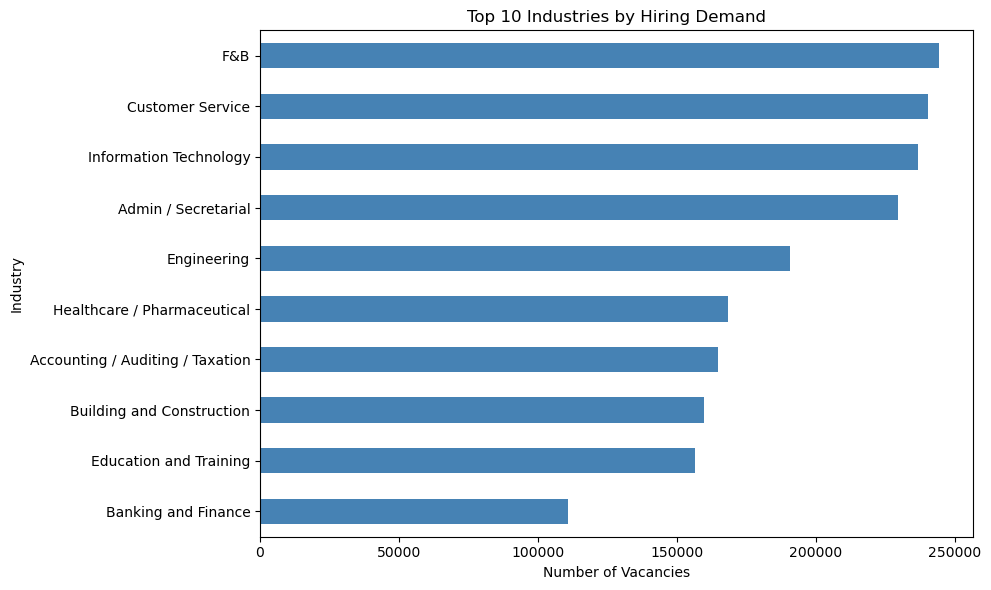

In [65]:
#Visualization:
plt.figure(figsize=(10,6))

industry_demand.head(10).sort_values().plot(
    kind='barh',
    color='steelblue'
)

plt.title('Top 10 Industries by Hiring Demand')
plt.xlabel('Number of Vacancies')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

#### Observation #2:

Record which industries attract the highest number of applications.

Business Insight

A high number of applications indicates strong interest from job seekers, but it may also suggest greater competition.

Dashboard Recommendation
Chart: Horizontal Bar Chart
KPI: Total Applications
Filters: Industry, Posting Date

## Business Question 3:  Which industries receive the most applications?
Business Objective

Understand where job seekers are applying the most.

Dataset Columns
categories
metadata_totalNumberJobApplication

In [66]:
#Analysis: 
applications = (
    demand_df.groupby('Industry')['metadata_totalNumberJobApplication']
    .sum()
    .sort_values(ascending=False)
)

applications.head(10)

Industry
Admin / Secretarial                 283872
Information Technology              245810
Accounting / Auditing / Taxation    197357
Banking and Finance                 175548
Engineering                         167378
Building and Construction           135375
Customer Service                    108853
Logistics / Supply Chain             89650
Human Resources                      82095
Marketing / Public Relations         70473
Name: metadata_totalNumberJobApplication, dtype: int64

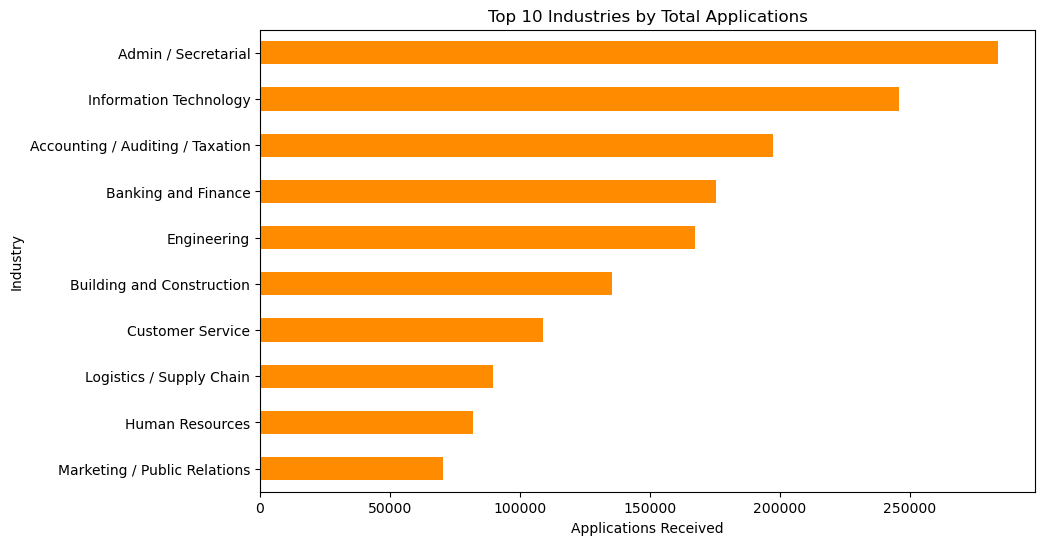

In [67]:
#Visualization
plt.figure(figsize=(10,6))

applications.head(10).sort_values().plot(
    kind='barh',
    color='darkorange'
)

plt.title("Top 10 Industries by Total Applications")
plt.xlabel("Applications Received")
plt.ylabel("Industry")

plt.show()

Observation from #3

Record which industries attract the highest number of applications.

Business Insight

A high number of applications indicates strong interest from job seekers, but it may also suggest greater competition.

Dashboard Recommendation
Chart: Horizontal Bar Chart
KPI: Total Applications
Filters: Industry, Posting Date

 # Business Question 4: Which industries are hardest to fill?
Business Objective

Identify industries where employers repeatedly repost vacancies.

Dataset Columns
categories
metadata_repostCount

In [68]:
#Analysis:
reposts = (
    demand_df.groupby('Industry')['metadata_repostCount']
    .mean()
    .sort_values(ascending=False)
)

reposts.head(10)

Industry
Public / Civil Service            0.101983
Hospitality                       0.096421
Engineering                       0.089952
Design                            0.076591
Customer Service                  0.073152
Precision Engineering             0.070748
Healthcare / Pharmaceutical       0.069156
Architecture / Interior Design    0.067585
Social Services                   0.067398
Travel / Tourism                  0.067269
Name: metadata_repostCount, dtype: float64

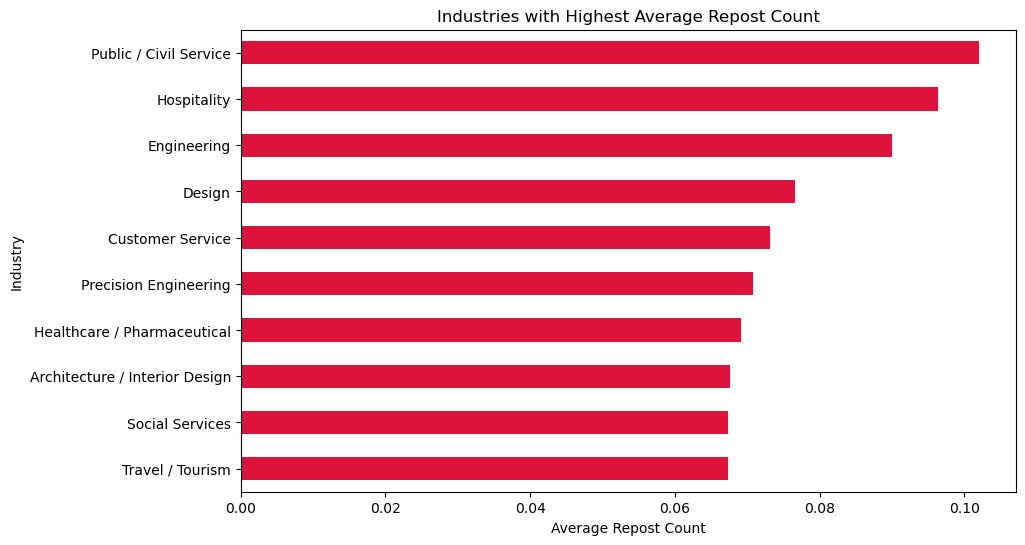

In [69]:
# Visualization
plt.figure(figsize=(10,6))

reposts.head(10).sort_values().plot(
    kind='barh',
    color='crimson'
)

plt.title("Industries with Highest Average Repost Count")
plt.xlabel("Average Repost Count")
plt.ylabel("Industry")

plt.show()

Observation from #4

Note which industries have the highest average repost count.

Business Insight

Frequent reposting may indicate skill shortages, hiring challenges, or difficult-to-fill roles.

Dashboard Recommendation
Chart: Horizontal Bar Chart
KPI: Average Repost Count
Filters: Industry

## How has hiring changed over time?

Step 1: Create a Year-Month column

In [70]:
trend_df = df.copy()

trend_df = df.copy()
trend_df["metadata_originalPostingDate"] = pd.to_datetime(
    trend_df["metadata_originalPostingDate"], errors="coerce"
)
trend_df = trend_df.dropna(subset=["metadata_originalPostingDate"])
trend_df["YearMonth"] = trend_df["metadata_originalPostingDate"].dt.to_period("M").astype(str)

trend = trend_df.groupby("YearMonth").size().reset_index(name="JobPostings")
trend


,YearMonth,JobPostings
0,2022-10,172
1,2022-11,590
2,2022-12,1184
3,2023-01,2764
4,2023-02,5855
5,2023-03,19414
6,2023-04,33094
7,2023-05,70213
8,2023-06,70410
9,2023-07,82878


In [71]:
#Job posting 

monthly_hiring = (
    trend_df
    .groupby("YearMonth")
    .size()
    .reset_index(name="JobPostings")
)
monthly_hiring

,YearMonth,JobPostings
0,2022-10,172
1,2022-11,590
2,2022-12,1184
3,2023-01,2764
4,2023-02,5855
5,2023-03,19414
6,2023-04,33094
7,2023-05,70213
8,2023-06,70410
9,2023-07,82878


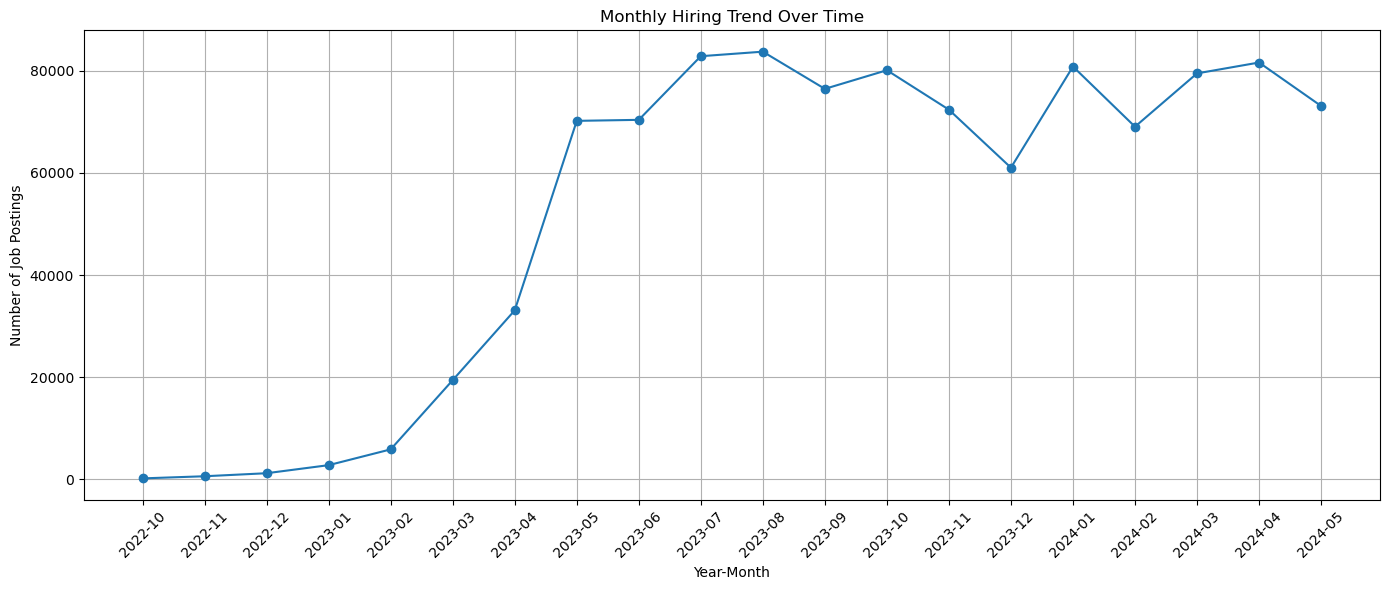

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    monthly_hiring["YearMonth"],
    monthly_hiring["JobPostings"],
    marker="o"
)

plt.title("Monthly Hiring Trend Over Time")

plt.xlabel("Year-Month")

plt.ylabel("Number of Job Postings")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

 # Business Question5: How has hiring changed over time?
Business Objective

Understand hiring trends over time to identify periods of increased or decreased recruitment.

Dataset Columns:

#### metadata_originalPostingDate
Data Preparation

In [73]:

monthly_hiring = (
    df.groupby("PostingMonth")
      .size()
      .reset_index(name="JobPostings")
      )

In [74]:
# Yearly Trend:
trend = (
    df.groupby("PostingYear")
      .size()
      .reset_index(name="JobPostings")
)

trend

,PostingYear,JobPostings
0,2022.0,1946
1,2023.0,658447
2,2024.0,384204


In [75]:
## Monthly Trend:

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

trend = (
    df.groupby("PostingMonth")
      .size()
      .reindex(month_order)
      .reset_index(name="JobPostings")
)

trend

,PostingMonth,JobPostings
0,January,83615
1,February,74924
2,March,98925
3,April,114736
4,May,143344
5,June,70410
6,July,82878
7,August,83766
8,September,76481
9,October,80303


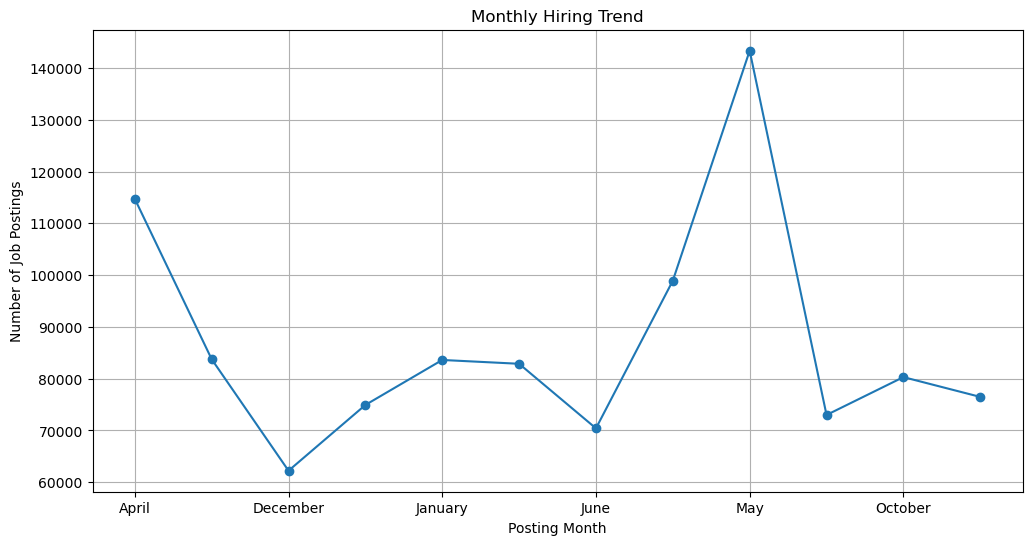

In [76]:
#Analysis:
monthly_hiring = (
    trend_df.groupby('PostingMonth')
    .size()
)

monthly_hiring.head()

#visualization:
plt.figure(figsize=(12,6))

monthly_hiring.plot(
    kind='line',
    marker='o'
)

plt.title("Monthly Hiring Trend")
plt.xlabel("Posting Month")
plt.ylabel("Number of Job Postings")

plt.grid(True)

plt.show()

In [77]:
df.shape

(1048585, 26)

## "How has hiring changed over time?"

There are two good ways to answer it.

### Option A (Recommended): Monthly hiring trend (best visualization)

This shows hiring activity over time and is more informative than just grouping by month names.

In [78]:
trend_df = df.copy()

monthly_hiring = (
    trend_df.assign(
        metadata_originalPostingDate=pd.to_datetime(
            trend_df["metadata_originalPostingDate"], errors="coerce"
        )
    )
    .dropna(subset=["metadata_originalPostingDate"])
    .groupby(
        pd.Grouper(key="metadata_originalPostingDate", freq="M")
    )
    .size()
    .to_period("M")
)

monthly_hiring.index = monthly_hiring.index.astype(str)
monthly_hiring


metadata_originalPostingDate
2022-10      172
2022-11      590
2022-12     1184
2023-01     2764
2023-02     5855
2023-03    19414
2023-04    33094
2023-05    70213
2023-06    70410
2023-07    82878
2023-08    83766
2023-09    76481
2023-10    80131
2023-11    72402
2023-12    61039
2024-01    80851
2024-02    69069
2024-03    79511
2024-04    81642
2024-05    73131
dtype: int64

## Option B: yearly totals:
Use PostingYear


In [79]:
yearly_hiring = (
    df.groupby("PostingYear")
      .size()
      .reset_index(name="JobPostings")
)
yearly_hiring

,PostingYear,JobPostings
0,2022.0,1946
1,2023.0,658447
2,2024.0,384204


## Recommended steps:
##### Part 02 (EDA): Use Option A (monthly trend with metadata_originalPostingDate.dt.to_period("M")). It provides a clear chronological trend.
##### Part 03 (Streamlit): Add filters using PostingYear, PostingQuarter, and PostingMonth that you

## Observation for Biz Question 5


Describe whether hiring is increasing, decreasing, or seasonal.

Business Insight

Hiring trends help job seekers identify the best periods to apply and help employers understand recruitment patterns.

Dashboard Recommendation
Chart: Line Chart
KPI: Number of Job Postings
Filters: Year, Month, Industry

# EDA Summary

The exploratory analysis answered the five business questions:

✔ Highest paying industries

✔ Greatest hiring demand

✔ Most applications

✔ Hardest to fill industries

✔ Hiring trends over time

The insights from this notebook will be visualized interactively in Part 03 using Streamlit.

## Why Feature Engg done and new columns are derived from existing data :
Feature engineering transforms existing raw data into meaningful business attributes that simplify analysis and visualization. By creating features such as PostingYear, PostingMonth, PostingQuarter, CompetitionIndex, and ApplicationRate during data preparation, we avoid repeating the same calculations in later stages. This makes the EDA and Streamlit dashboard simpler, more consistent, and easier to maintain while providing business-friendly metrics for answering the project questions